# NAME: FARHANKHAN PATHAN
# ROLL NO.: 61
# CLASS: CSAI_D-3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("uber.csv")
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.50,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,27835199,2009-07-17 20:04:56.0000002,7.70,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,44984355,2009-08-24 21:45:00.00000061,12.90,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1.0
3,25894730,2009-06-26 08:22:21.0000001,5.30,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3.0
4,17610152,2014-08-28 17:47:00.000000188,16.00,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5.0
...,...,...,...,...,...,...,...,...,...
35720,13789976,2009-03-17 16:40:34.0000002,4.10,2009-03-17 16:40:34 UTC,-73.989167,40.762935,-73.991962,40.754702,3.0
35721,51786630,2014-06-12 20:03:00.000000201,6.00,2014-06-12 20:03:00 UTC,-73.976287,40.760280,-73.983277,40.763827,5.0
35722,50738790,2013-04-09 10:21:38.0000002,20.83,2013-04-09 10:21:38 UTC,-73.988428,40.670634,-74.013862,40.714818,1.0
35723,3187125,2011-04-03 12:44:31.0000002,16.50,2011-04-03 12:44:31 UTC,-74.001600,40.727635,-73.983275,40.781579,1.0


1. **Pre-process the dataset**.

In [ ]:
df.isnull().sum()


,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,1
pickup_latitude,1
dropoff_longitude,1
dropoff_latitude,1
passenger_count,1


In [ ]:
df.dropna(inplace=True)


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)


In [ ]:
df = df[df['fare_amount'] > 0]
df = df[df['passenger_count'] > 0]


In [ ]:
df.isnull().sum()


,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0


In [ ]:
df.drop(columns=['key'], inplace=True)


In [ ]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [ ]:
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year


In [ ]:
df.drop(columns=['pickup_datetime'], inplace=True)


**2. Identify outliers.**

A. Scatter Plot

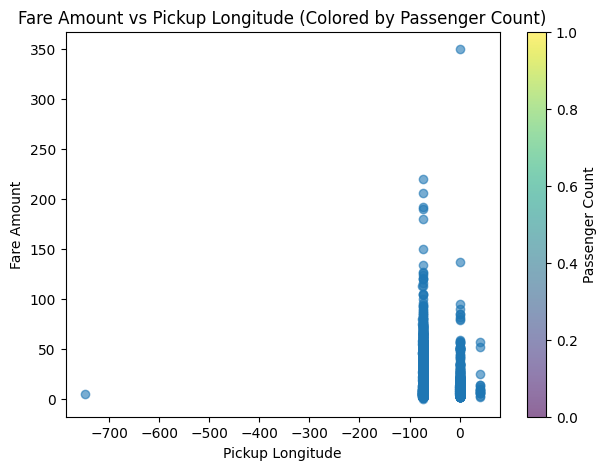

In [ ]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    df['pickup_longitude'],
    df['fare_amount'],
    # c=df['passenger_count'],
    # cmap='viridis',
    alpha=0.6
)

plt.colorbar(scatter, label="Passenger Count")
plt.xlabel("Pickup Longitude")
plt.ylabel("Fare Amount")
plt.title("Fare Amount vs Pickup Longitude (Colored by Passenger Count)")
plt.show()





B. Box Plot

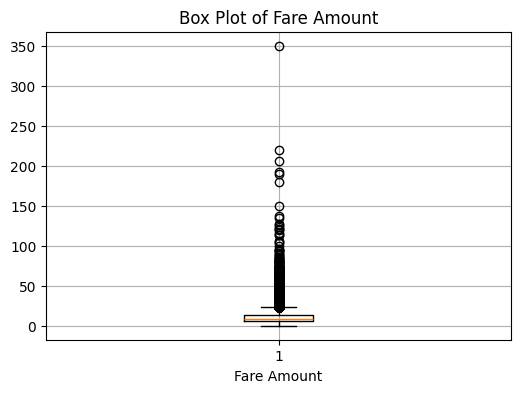

In [ ]:
plt.figure(figsize=(6, 4))

box = plt.boxplot(df['fare_amount'])
plt.title("Box Plot of Fare Amount")
plt.xlabel("Fare Amount")
plt.grid(True)
plt.show()

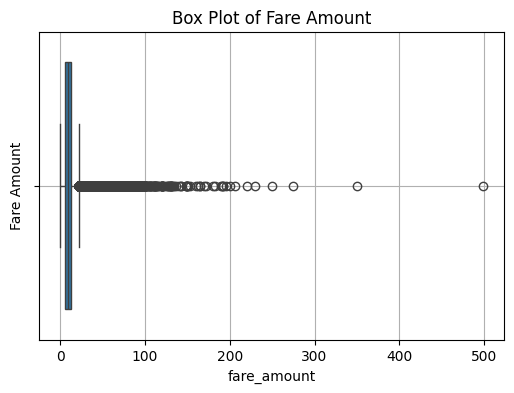

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['fare_amount'])
plt.title("Box Plot of Fare Amount")
plt.ylabel("Fare Amount")
plt.grid(True)
plt.show()


Identifying Outliers

In [ ]:
def detect_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper


In [ ]:
fare_lower, fare_upper = detect_outliers_iqr(df['fare_amount'])

fare_lower, fare_upper


(np.float64(-4.350000000000001), np.float64(23.25))

In [ ]:
df_no_fare_outliers = df[
    (df['fare_amount'] >= fare_lower) &
    (df['fare_amount'] <= fare_upper)
]


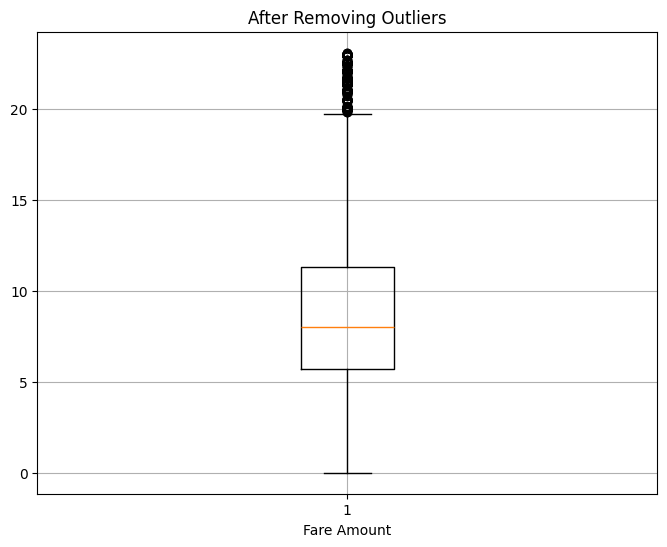

In [ ]:
plt.figure(figsize=(8, 6))

box = plt.boxplot(df_no_fare_outliers['fare_amount'])
plt.title("After Removing Outliers")
plt.xlabel("Fare Amount")
plt.grid(True)
plt.show()

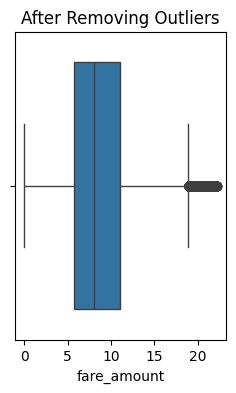

In [ ]:
plt.figure(figsize=(6, 4))

plt.subplot(1, 2, 2)
sns.boxplot(x=df_no_fare_outliers['fare_amount'])
plt.title("After Removing Outliers")
plt.show()


3. Check the correlation


In [ ]:
df_numeric = df.select_dtypes(include=['float64', 'int64'])


In [ ]:
corr_matrix = df_numeric.corr()
corr_matrix


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
Unnamed: 0,1.000000,0.000592,0.000118,-0.000249,0.000122,0.000431,0.001998
fare_amount,0.000592,1.000000,0.010420,-0.008441,0.009064,-0.011098,0.009616
pickup_longitude,0.000118,0.010420,1.000000,-0.815878,0.833047,-0.846383,-0.000247
pickup_latitude,-0.000249,-0.008441,-0.815878,1.000000,-0.774615,0.701959,-0.001695
dropoff_longitude,0.000122,0.009064,0.833047,-0.774615,1.000000,-0.916715,0.000073
dropoff_latitude,0.000431,-0.011098,-0.846383,0.701959,-0.916715,1.000000,-0.000686
passenger_count,0.001998,0.009616,-0.000247,-0.001695,0.000073,-0.000686,1.000000


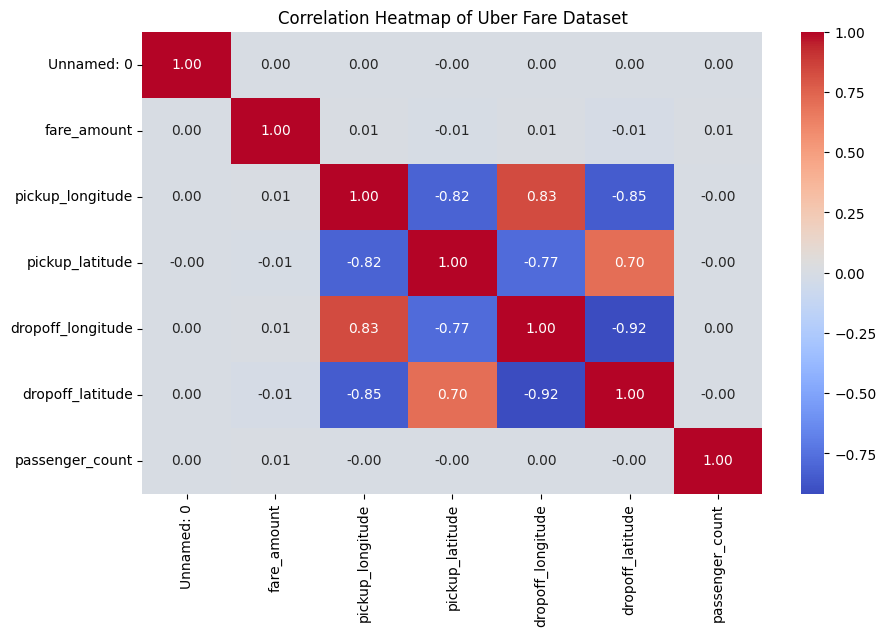

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap of Uber Fare Dataset")
plt.show()
